# Финальный проект — вариант 3

## A/B-тест новой цены премиум-подписки

В этой версии код идёт линейно сверху вниз: **без собственных функций и
без циклов**. Мы:

1. загружаем шесть файлов;
2. проверяем ошибки и расхождения;
3. собираем таблицу уровня пользователя;
4. проверяем баланс и две контрольные группы;
5. считаем продуктовые метрики;
6. проверяем статистическую значимость;
7. принимаем бизнес-решение.

**Главный вывод:** эксперимент нельзя считать успешным. Рост цены поднял
выручку на одного платящего, но значимо снизил конверсию. `ARPU` не вырос
статистически значимо, поэтому раскатывать новую цену на всех не стоит.

## 1. Что проверяем

В тестовой группе изменилась цена премиум-подписки для части новых
пользователей из нескольких стран и платёжных систем. Цена пробного
периода не менялась.

Единица анализа — **пользователь**, а не отдельная транзакция.

Основные метрики:

- `CR payer` — доля пользователей с любой оплатой;
- `CR premium` — доля пользователей, купивших `premium_no_trial`;
- `ARPU` — общая выручка на одного пользователя;
- `Premium ARPU` — выручка от обычного премиума на пользователя;
- `ARPPU` — выручка на одного платящего, вспомогательная метрика;
- `CR trial` — конверсия в пробный премиум, цена которого не менялась.

Уровень значимости: `alpha = 0.05`.

## 2. Импорт библиотек

Используем готовые инструменты:

- `pandas` — таблицы и расчёты;
- `matplotlib` и `seaborn` — графики;
- `scipy` и `statsmodels` — статистические тесты.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/raw")
ALPHA = 0.05

## 3. Загрузка шести файлов

Таблицы `users` содержат всех участников эксперимента. Таблицы
`transactions` содержат только покупки.

In [2]:
users_control_1 = pd.read_csv(
    DATA_DIR / "Проект_3_users_control_1.csv",
    sep=";",
)
users_control_2 = pd.read_csv(
    DATA_DIR / "Проект_3_users_control_2.csv",
    sep=";",
)
users_test = pd.read_csv(
    DATA_DIR / "Проект_3_users_test.csv",
    sep=";",
)

transactions_control_1 = pd.read_csv(
    DATA_DIR / "Проект_3_transactions_control_1.csv",
    sep=";",
)
transactions_control_2 = pd.read_csv(
    DATA_DIR / "Проект_3_transactions_control_2.csv",
    sep=";",
)
transactions_test = pd.read_csv(
    DATA_DIR / "Проект_3_transactions_test.csv",
    sep=";",
)

print("users_control_1:", users_control_1.shape)
print("users_control_2:", users_control_2.shape)
print("users_test:", users_test.shape)
print()
print("transactions_control_1:", transactions_control_1.shape)
print("transactions_control_2:", transactions_control_2.shape)
print("transactions_test:", transactions_test.shape)

users_control_1: (4340, 13)
users_control_2: (4264, 13)
users_test: (4308, 13)

transactions_control_1: (1007, 8)
transactions_control_2: (328, 8)
transactions_test: (273, 8)


## 4. Добавляем названия групп

После этого можно объединить однотипные файлы в две таблицы.

In [3]:
users_control_1["group"] = "control_1"
users_control_2["group"] = "control_2"
users_test["group"] = "test"

transactions_control_1["group"] = "control_1"
transactions_control_2["group"] = "control_2"
transactions_test["group"] = "test"

users = pd.concat(
    [users_control_1, users_control_2, users_test],
    ignore_index=True,
)

transactions = pd.concat(
    [
        transactions_control_1,
        transactions_control_2,
        transactions_test,
    ],
    ignore_index=True,
)

users.shape, transactions.shape

((12912, 14), (1608, 9))

## 5. Проверка качества данных

Сначала смотрим на пропуски `uid` и точные повторы строк.

В `transactions_control_1` есть 630 служебных строк без пользователя и
большинства бизнес-полей. Их нельзя связать с участниками эксперимента,
поэтому удаляем только эти строки.

In [4]:
quality = pd.DataFrame(
    {
        "file": [
            "transactions_control_1",
            "transactions_control_2",
            "transactions_test",
        ],
        "rows": [
            len(transactions_control_1),
            len(transactions_control_2),
            len(transactions_test),
        ],
        "missing_uid": [
            transactions_control_1["uid"].isna().sum(),
            transactions_control_2["uid"].isna().sum(),
            transactions_test["uid"].isna().sum(),
        ],
        "exact_duplicates_all_rows": [
            transactions_control_1.duplicated().sum(),
            transactions_control_2.duplicated().sum(),
            transactions_test.duplicated().sum(),
        ],
    }
)

quality

,file,rows,missing_uid,exact_duplicates_all_rows
0,transactions_control_1,1007,630,650
1,transactions_control_2,328,0,5
2,transactions_test,273,0,7


In [5]:
transactions_valid = transactions.dropna(subset=["uid"]).copy()
transactions_valid["uid"] = transactions_valid["uid"].astype("int64")
transactions_valid["payment_id"] = (
    transactions_valid["payment_id"].astype("int64")
)

duplicate_check = pd.DataFrame(
    {
        "group": ["control_1", "control_2", "test"],
        "valid_rows": [
            len(
                transactions_valid[
                    transactions_valid["group"] == "control_1"
                ]
            ),
            len(
                transactions_valid[
                    transactions_valid["group"] == "control_2"
                ]
            ),
            len(
                transactions_valid[
                    transactions_valid["group"] == "test"
                ]
            ),
        ],
        "exact_duplicates": [
            transactions_valid[
                transactions_valid["group"] == "control_1"
            ].duplicated().sum(),
            transactions_valid[
                transactions_valid["group"] == "control_2"
            ].duplicated().sum(),
            transactions_valid[
                transactions_valid["group"] == "test"
            ].duplicated().sum(),
        ],
    }
)

duplicate_check

,group,valid_rows,exact_duplicates
0,control_1,377,21
1,control_2,328,5
2,test,273,7


In [6]:
transaction_links = transactions_valid[
    ["group", "uid"]
].merge(
    users[["group", "uid"]].drop_duplicates(),
    on=["group", "uid"],
    how="left",
    indicator=True,
)

print(
    "Транзакций без пользователя в своей группе:",
    (transaction_links["_merge"] == "left_only").sum(),
)

Транзакций без пользователя в своей группе: 0


### Почему не удаляем все одинаковые транзакции

Одинаковые строки не обязательно являются техническими дублями:
пользователь мог несколько раз купить одинаковый пакет. Поэтому
сверяем сумму транзакций с готовым `total_revenue` из таблицы
пользователей.

Если бездумно вызвать `drop_duplicates()`, даже полностью совпадающая
контрольная группа перестанет сходиться по выручке. Поэтому:

- `total_revenue` используем как источник общей выручки;
- транзакции используем для определения типа покупки;
- точные повторы не удаляем автоматически.

In [7]:
transaction_revenue = transactions_valid.groupby(
    ["group", "uid"],
    as_index=False,
).agg(
    transactions_revenue=("revenue", "sum"),
)

revenue_check = users[
    ["group", "uid", "total_revenue"]
].merge(
    transaction_revenue,
    on=["group", "uid"],
    how="left",
)

revenue_check["transactions_revenue"] = (
    revenue_check["transactions_revenue"].fillna(0)
)
revenue_check["difference"] = (
    revenue_check["transactions_revenue"]
    - revenue_check["total_revenue"]
)
revenue_check["mismatch"] = revenue_check["difference"].ne(0)

reconciliation = revenue_check.groupby(
    "group",
    as_index=False,
).agg(
    users_revenue=("total_revenue", "sum"),
    transactions_revenue=("transactions_revenue", "sum"),
    mismatch_users=("mismatch", "sum"),
)

reconciliation["difference"] = (
    reconciliation["transactions_revenue"]
    - reconciliation["users_revenue"]
)

reconciliation

,group,users_revenue,transactions_revenue,mismatch_users,difference
0,control_1,2581267,"2,612,311.0000",2,"31,044.0000"
1,control_2,1920438,"1,920,438.0000",0,0.0000
2,test,2300818,"2,344,901.0000",1,"44,083.0000"


Расхождения локальные:

- `control_2` сходится полностью;
- в `control_1` транзакции выше `total_revenue` на 31 044;
- в `test` транзакции выше `total_revenue` на 44 083.

Поэтому для `ARPU`, `ARPPU` и общей конверсии берём
`users.total_revenue`. Это защищает результат от ошибочных операций в
журнале транзакций.

### Дополнительная проблема с датами

Если разобрать строки как обычный формат `YYYY-MM-DD`, часть оплат
окажется раньше регистрации. Это указывает на смешанный порядок месяца
и дня или на ошибки в исходных временных метках.

Мы не фильтруем эксперимент по этим датам: состав групп уже задан в
`users`, а фильтр по повреждённому времени мог бы удалить реальные
покупки.

In [8]:
date_check = transactions_valid[
    ["group", "joined_at", "paid_at"]
].copy()

date_check["joined_default"] = pd.to_datetime(
    date_check["joined_at"],
    errors="coerce",
)
date_check["paid_default"] = pd.to_datetime(
    date_check["paid_at"],
    errors="coerce",
)
date_check["paid_before_joined"] = (
    date_check["paid_default"] < date_check["joined_default"]
)

date_check.groupby("group", as_index=False).agg(
    transactions=("paid_before_joined", "size"),
    paid_before_joined=("paid_before_joined", "sum"),
)

,group,transactions,paid_before_joined
0,control_1,377,55
1,control_2,328,60
2,test,273,47


## 6. Собираем таблицу уровня пользователя

Для каждого пользователя создаём четыре признака:

- `payer` — была ли любая оплата;
- `premium_buyer` — покупался ли обычный премиум;
- `premium_revenue` — выручка от обычного премиума;
- `trial_buyer` — покупался ли пробный премиум.

Перед объединением транзакции агрегируются до уровня пользователя, чтобы
повторные покупки не размножили строки.

In [9]:
premium_by_user = transactions_valid[
    transactions_valid["product_type"] == "premium_no_trial"
].groupby(
    ["group", "uid"],
    as_index=False,
).agg(
    premium_revenue=("revenue", "sum"),
    premium_transactions=("revenue", "size"),
)

trial_by_user = transactions_valid[
    transactions_valid["product_type"] == "trial_premium"
][["group", "uid"]].drop_duplicates()

trial_by_user["trial_buyer"] = True

experiment = users.merge(
    premium_by_user,
    on=["group", "uid"],
    how="left",
)

experiment = experiment.merge(
    trial_by_user,
    on=["group", "uid"],
    how="left",
)

experiment["premium_revenue"] = (
    experiment["premium_revenue"].fillna(0)
)
experiment["premium_transactions"] = (
    experiment["premium_transactions"].fillna(0)
)
experiment["payer"] = experiment["total_revenue"] > 0
experiment["premium_buyer"] = experiment["premium_revenue"] > 0
experiment["trial_buyer"] = experiment["trial_buyer"].eq(True)

print("Строк в users:", len(users))
print("Строк в experiment:", len(experiment))
print("Повторяющихся uid внутри группы:", experiment.duplicated(["group", "uid"]).sum())

Строк в users: 12912
Строк в experiment: 12912
Повторяющихся uid внутри группы: 0


## 7. Проверяем баланс групп

До проверки результата убеждаемся, что группы похожи по признакам,
которые существовали до оплаты.

- для категорий используем критерий хи-квадрат;
- для числовых признаков — критерий Краскела—Уоллиса.

Если `p-value > 0.05`, значимых различий не обнаружено.

In [10]:
country_test = stats.chi2_contingency(
    pd.crosstab(experiment["group"], experiment["country"])
)
gender_test = stats.chi2_contingency(
    pd.crosstab(experiment["group"], experiment["gender"])
)

age_test = stats.kruskal(
    experiment.loc[experiment["group"] == "control_1", "age"],
    experiment.loc[experiment["group"] == "control_2", "age"],
    experiment.loc[experiment["group"] == "test", "age"],
)
attraction_test = stats.kruskal(
    experiment.loc[
        experiment["group"] == "control_1",
        "attraction_coeff",
    ],
    experiment.loc[
        experiment["group"] == "control_2",
        "attraction_coeff",
    ],
    experiment.loc[
        experiment["group"] == "test",
        "attraction_coeff",
    ],
)
views_test = stats.kruskal(
    experiment.loc[experiment["group"] == "control_1", "views_count"],
    experiment.loc[experiment["group"] == "control_2", "views_count"],
    experiment.loc[experiment["group"] == "test", "views_count"],
)

balance = pd.DataFrame(
    {
        "feature": [
            "country",
            "gender",
            "age",
            "attraction_coeff",
            "views_count",
        ],
        "p_value": [
            country_test.pvalue,
            gender_test.pvalue,
            age_test.pvalue,
            attraction_test.pvalue,
            views_test.pvalue,
        ],
    }
)

balance["significant_difference"] = balance["p_value"] < ALPHA
balance

,feature,p_value,significant_difference
0,country,0.6582,False
1,gender,0.5075,False
2,age,0.5740,False
3,attraction_coeff,0.8769,False
4,views_count,0.4555,False


Значимых различий по стране, полу, возрасту, коэффициенту
привлекательности и числу просмотров нет. Баланс рандомизации выглядит
приемлемо.

## 8. A/A-проверка двух контролей

До объединения `control_1` и `control_2` проверяем, не отличаются ли они
сами по себе.

- конверсии сравниваем z-тестом долей;
- среднюю выручку сравниваем t-тестом Уэлча.

In [11]:
control_1 = experiment[experiment["group"] == "control_1"]
control_2 = experiment[experiment["group"] == "control_2"]

aa_payer_z, aa_payer_p = proportions_ztest(
    [
        control_1["payer"].sum(),
        control_2["payer"].sum(),
    ],
    [
        len(control_1),
        len(control_2),
    ],
)

aa_premium_z, aa_premium_p = proportions_ztest(
    [
        control_1["premium_buyer"].sum(),
        control_2["premium_buyer"].sum(),
    ],
    [
        len(control_1),
        len(control_2),
    ],
)

aa_arpu = stats.ttest_ind(
    control_1["total_revenue"],
    control_2["total_revenue"],
    equal_var=False,
)

aa_premium_arpu = stats.ttest_ind(
    control_1["premium_revenue"],
    control_2["premium_revenue"],
    equal_var=False,
)

aa_results = pd.DataFrame(
    {
        "metric": [
            "CR payer",
            "CR premium",
            "ARPU",
            "Premium ARPU",
        ],
        "p_value": [
            aa_payer_p,
            aa_premium_p,
            aa_arpu.pvalue,
            aa_premium_arpu.pvalue,
        ],
    }
)

aa_results["significant_difference"] = aa_results["p_value"] < ALPHA
aa_results

,metric,p_value,significant_difference
0,CR payer,0.9308,False
1,CR premium,0.7332,False
2,ARPU,0.2628,False
3,Premium ARPU,0.9066,False


Все `p-value` выше 0.05. Статистических оснований считать две контрольные
группы разными нет, поэтому для основной проверки объединяем их. Так
контроль становится больше, а оценка — точнее.

## 9. Считаем метрики по трём группам

Формулы:

- `conversion = payers / users`;
- `ARPU = revenue / users`;
- `ARPPU = revenue / payers`.

In [12]:
metrics = experiment.groupby(
    "group",
    as_index=False,
).agg(
    users=("uid", "size"),
    payers=("payer", "sum"),
    revenue=("total_revenue", "sum"),
    premium_buyers=("premium_buyer", "sum"),
    premium_revenue=("premium_revenue", "sum"),
    trial_buyers=("trial_buyer", "sum"),
)

metrics["conversion"] = metrics["payers"] / metrics["users"]
metrics["arpu"] = metrics["revenue"] / metrics["users"]
metrics["arppu"] = metrics["revenue"] / metrics["payers"]

metrics["premium_conversion"] = (
    metrics["premium_buyers"] / metrics["users"]
)
metrics["premium_arpu"] = (
    metrics["premium_revenue"] / metrics["users"]
)
metrics["premium_arppu"] = (
    metrics["premium_revenue"] / metrics["premium_buyers"]
)
metrics["trial_conversion"] = (
    metrics["trial_buyers"] / metrics["users"]
)

metrics

,group,users,payers,revenue,premium_buyers,premium_revenue,trial_buyers,conversion,arpu,arppu,premium_conversion,premium_arpu,premium_arppu,trial_conversion
0,control_1,4340,192,2581267,99,"779,259.0000",67,0.0442,594.7620,"13,444.0990",0.0228,179.5528,"7,871.3030",0.0154
1,control_2,4264,187,1920438,102,"744,809.0000",53,0.0439,450.3841,"10,269.7219",0.0239,174.6738,"7,302.0490",0.0124
2,test,4308,146,2300818,67,"810,706.0000",61,0.0339,534.0803,"15,759.0274",0.0156,188.1862,"12,100.0896",0.0142


## 10. Визуальное сравнение

Сначала сравним конверсии. Оси начинаются с нуля, поэтому разница не
преувеличена.

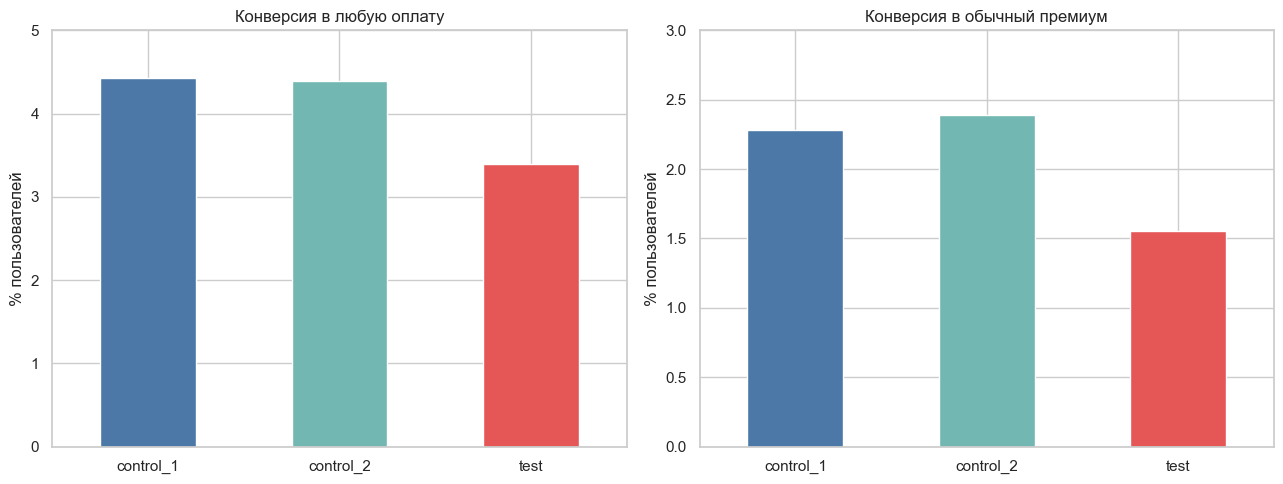

In [13]:
metrics_plot = metrics.set_index("group").loc[
    ["control_1", "control_2", "test"]
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

(metrics_plot["conversion"] * 100).plot.bar(
    ax=axes[0],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[0].set_title("Конверсия в любую оплату")
axes[0].set_xlabel("")
axes[0].set_ylabel("% пользователей")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0, 5)

(metrics_plot["premium_conversion"] * 100).plot.bar(
    ax=axes[1],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[1].set_title("Конверсия в обычный премиум")
axes[1].set_xlabel("")
axes[1].set_ylabel("% пользователей")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, 3)

plt.tight_layout()
plt.show()

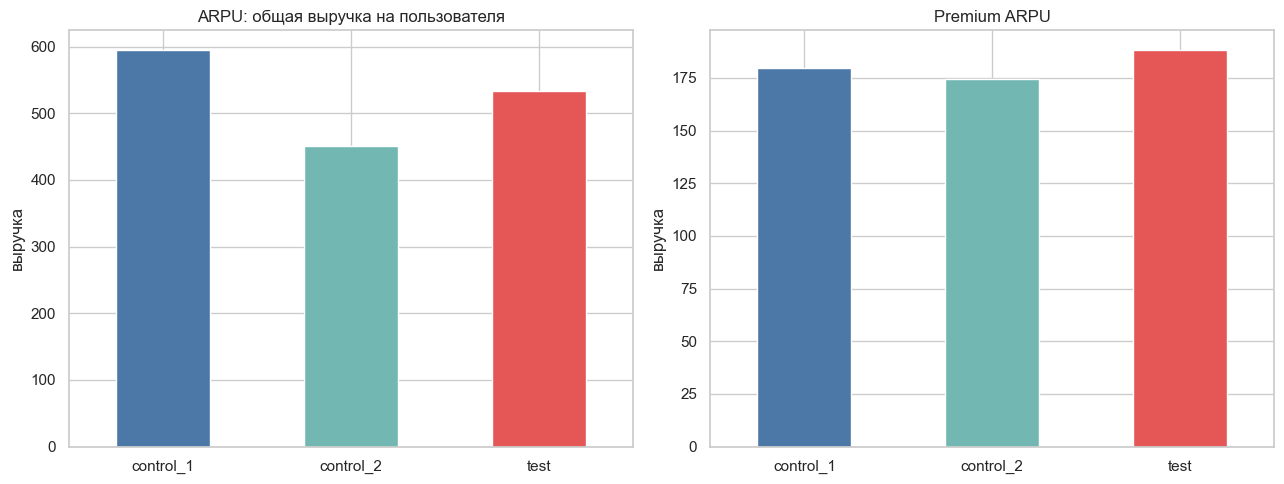

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_plot["arpu"].plot.bar(
    ax=axes[0],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[0].set_title("ARPU: общая выручка на пользователя")
axes[0].set_xlabel("")
axes[0].set_ylabel("выручка")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0)

metrics_plot["premium_arpu"].plot.bar(
    ax=axes[1],
    color=["#4C78A8", "#72B7B2", "#E45756"],
)
axes[1].set_title("Premium ARPU")
axes[1].set_xlabel("")
axes[1].set_ylabel("выручка")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0)

plt.tight_layout()
plt.show()

По описательным метрикам видно:

- конверсия теста ниже;
- выручка на пользователя немного выше объединённого контроля;
- выручка на платящего выше, что логично при более высокой цене.

Но по одному графику нельзя решить, случайны различия или нет. Нужны
статистические тесты.

## 11. Объединяем контроли

In [15]:
experiment["comparison"] = experiment["group"].replace(
    {
        "control_1": "control",
        "control_2": "control",
    }
)

pooled_metrics = experiment.groupby(
    "comparison",
    as_index=False,
).agg(
    users=("uid", "size"),
    payers=("payer", "sum"),
    revenue=("total_revenue", "sum"),
    premium_buyers=("premium_buyer", "sum"),
    premium_revenue=("premium_revenue", "sum"),
    trial_buyers=("trial_buyer", "sum"),
)

pooled_metrics["conversion"] = (
    pooled_metrics["payers"] / pooled_metrics["users"]
)
pooled_metrics["arpu"] = (
    pooled_metrics["revenue"] / pooled_metrics["users"]
)
pooled_metrics["arppu"] = (
    pooled_metrics["revenue"] / pooled_metrics["payers"]
)
pooled_metrics["premium_conversion"] = (
    pooled_metrics["premium_buyers"] / pooled_metrics["users"]
)
pooled_metrics["premium_arpu"] = (
    pooled_metrics["premium_revenue"] / pooled_metrics["users"]
)
pooled_metrics["premium_arppu"] = (
    pooled_metrics["premium_revenue"]
    / pooled_metrics["premium_buyers"]
)
pooled_metrics["trial_conversion"] = (
    pooled_metrics["trial_buyers"] / pooled_metrics["users"]
)

pooled_metrics

,comparison,users,payers,revenue,premium_buyers,premium_revenue,trial_buyers,conversion,arpu,arppu,premium_conversion,premium_arpu,premium_arppu,trial_conversion
0,control,8604,379,4501705,201,"1,524,068.0000",120,0.0440,523.2107,"11,877.8496",0.0234,177.1348,"7,582.4279",0.0139
1,test,4308,146,2300818,67,"810,706.0000",61,0.0339,534.0803,"15,759.0274",0.0156,188.1862,"12,100.0896",0.0142


## 12. Проверка гипотез

Нулевые гипотезы:

- конверсии теста и контроля равны;
- средняя выручка на пользователя одинакова.

Альтернативные гипотезы: показатели отличаются.

Для конверсий используем z-тест, для средних — t-тест Уэлча. Дополнительно
считаем 95% доверительные интервалы разницы.

In [16]:
test_group = experiment[experiment["comparison"] == "test"]
control_group = experiment[experiment["comparison"] == "control"]

payer_z, payer_p = proportions_ztest(
    [
        test_group["payer"].sum(),
        control_group["payer"].sum(),
    ],
    [
        len(test_group),
        len(control_group),
    ],
)

premium_z, premium_p = proportions_ztest(
    [
        test_group["premium_buyer"].sum(),
        control_group["premium_buyer"].sum(),
    ],
    [
        len(test_group),
        len(control_group),
    ],
)

trial_z, trial_p = proportions_ztest(
    [
        test_group["trial_buyer"].sum(),
        control_group["trial_buyer"].sum(),
    ],
    [
        len(test_group),
        len(control_group),
    ],
)

arpu_test = stats.ttest_ind(
    test_group["total_revenue"],
    control_group["total_revenue"],
    equal_var=False,
)

premium_arpu_test = stats.ttest_ind(
    test_group["premium_revenue"],
    control_group["premium_revenue"],
    equal_var=False,
)

arpu_interval = CompareMeans(
    DescrStatsW(test_group["total_revenue"]),
    DescrStatsW(control_group["total_revenue"]),
).tconfint_diff(usevar="unequal")

premium_arpu_interval = CompareMeans(
    DescrStatsW(test_group["premium_revenue"]),
    DescrStatsW(control_group["premium_revenue"]),
).tconfint_diff(usevar="unequal")

In [17]:
test_cr = test_group["payer"].mean()
control_cr = control_group["payer"].mean()

test_premium_cr = test_group["premium_buyer"].mean()
control_premium_cr = control_group["premium_buyer"].mean()

payer_interval = confint_proportions_2indep(
    test_group["payer"].sum(),
    len(test_group),
    control_group["payer"].sum(),
    len(control_group),
    method="wald",
)

premium_interval = confint_proportions_2indep(
    test_group["premium_buyer"].sum(),
    len(test_group),
    control_group["premium_buyer"].sum(),
    len(control_group),
    method="wald",
)

In [18]:
test_arpu = test_group["total_revenue"].mean()
control_arpu = control_group["total_revenue"].mean()

test_premium_arpu = test_group["premium_revenue"].mean()
control_premium_arpu = control_group["premium_revenue"].mean()

test_trial_cr = test_group["trial_buyer"].mean()
control_trial_cr = control_group["trial_buyer"].mean()

results = pd.DataFrame(
    {
        "metric": [
            "CR payer, п.п.",
            "CR premium, п.п.",
            "ARPU",
            "Premium ARPU",
            "CR trial, п.п.",
        ],
        "control": [
            control_cr * 100,
            control_premium_cr * 100,
            control_arpu,
            control_premium_arpu,
            control_trial_cr * 100,
        ],
        "test": [
            test_cr * 100,
            test_premium_cr * 100,
            test_arpu,
            test_premium_arpu,
            test_trial_cr * 100,
        ],
        "absolute_effect": [
            (test_cr - control_cr) * 100,
            (test_premium_cr - control_premium_cr) * 100,
            test_arpu - control_arpu,
            test_premium_arpu - control_premium_arpu,
            (test_trial_cr - control_trial_cr) * 100,
        ],
        "relative_effect_pct": [
            (test_cr / control_cr - 1) * 100,
            (test_premium_cr / control_premium_cr - 1) * 100,
            (test_arpu / control_arpu - 1) * 100,
            (
                test_premium_arpu
                / control_premium_arpu
                - 1
            )
            * 100,
            (test_trial_cr / control_trial_cr - 1) * 100,
        ],
        "p_value": [
            payer_p,
            premium_p,
            arpu_test.pvalue,
            premium_arpu_test.pvalue,
            trial_p,
        ],
    }
)

results["significant"] = results["p_value"] < ALPHA
results

,metric,control,test,absolute_effect,relative_effect_pct,p_value,significant
0,"CR payer, п.п.",4.4049,3.3890,-1.0159,-23.0624,0.0059,True
1,"CR premium, п.п.",2.3361,1.5552,-0.7809,-33.4262,0.0033,True
2,ARPU,523.2107,534.0803,10.8696,2.0775,0.9070,False
3,Premium ARPU,177.1348,188.1862,11.0513,6.2389,0.8117,False
4,"CR trial, п.п.",1.3947,1.4160,0.0213,1.5251,0.9228,False


In [19]:
intervals = pd.DataFrame(
    {
        "metric": [
            "CR payer, п.п.",
            "CR premium, п.п.",
            "ARPU",
            "Premium ARPU",
        ],
        "ci_95_low": [
            payer_interval[0] * 100,
            premium_interval[0] * 100,
            arpu_interval[0],
            premium_arpu_interval[0],
        ],
        "ci_95_high": [
            payer_interval[1] * 100,
            premium_interval[1] * 100,
            arpu_interval[1],
            premium_arpu_interval[1],
        ],
    }
)

intervals

,metric,ci_95_low,ci_95_high
0,"CR payer, п.п.",-1.7087,-0.3231
1,"CR premium, п.п.",-1.2691,-0.2926
2,ARPU,-171.4166,193.1558
3,Premium ARPU,-79.9059,102.0086


### Интерпретация тестов

1. **Общая конверсия в оплату** снизилась с 4.40% до 3.39%:
   эффект `−1.02 п.п.` или примерно `−23%`, `p = 0.0059`.
2. **Конверсия в обычный премиум** снизилась с 2.34% до 1.56%:
   эффект `−0.78 п.п.` или примерно `−33%`, `p = 0.0033`.
3. **ARPU** вырос только на 2.1%, но результат незначим:
   `p = 0.907`, доверительный интервал включает и падение, и рост.
4. **Premium ARPU** вырос на 6.2%, но тоже незначимо:
   `p = 0.812`.
5. **Конверсия в trial-премиум**, цена которого не менялась, почти
   одинакова: `p = 0.923`. Это полезная контрольная проверка.

## 13. Что произошло с выручкой на платящего

`ARPPU` считается только среди тех, кто уже оплатил. Эта группа
сформировалась после воздействия цены, поэтому `ARPPU` нельзя считать
главным критерием успеха. Но он помогает понять механику результата.

In [20]:
test_payers = test_group[
    test_group["payer"]
]["total_revenue"]
control_payers = control_group[
    control_group["payer"]
]["total_revenue"]

arppu_test = stats.ttest_ind(
    test_payers,
    control_payers,
    equal_var=False,
)

test_premium_buyers = test_group[
    test_group["premium_buyer"]
]["premium_revenue"]
control_premium_buyers = control_group[
    control_group["premium_buyer"]
]["premium_revenue"]

premium_arppu_test = stats.ttest_ind(
    test_premium_buyers,
    control_premium_buyers,
    equal_var=False,
)

arppu_results = pd.DataFrame(
    {
        "metric": ["ARPPU", "Premium ARPPU"],
        "control": [
            control_payers.mean(),
            control_premium_buyers.mean(),
        ],
        "test": [
            test_payers.mean(),
            test_premium_buyers.mean(),
        ],
        "relative_effect_pct": [
            (
                test_payers.mean()
                / control_payers.mean()
                - 1
            )
            * 100,
            (
                test_premium_buyers.mean()
                / control_premium_buyers.mean()
                - 1
            )
            * 100,
        ],
        "p_value": [
            arppu_test.pvalue,
            premium_arppu_test.pvalue,
        ],
    }
)

arppu_results

,metric,control,test,relative_effect_pct,p_value
0,ARPPU,"11,877.8496","15,759.0274",32.6758,0.0546
1,Premium ARPPU,"7,582.4279","12,100.0896",59.5807,0.0587


Выручка на платящего действительно выше, но оба `p-value` немного выше
0.05. Даже если бы рост `ARPPU` был значимым, он не отменял бы основной
результат: пользователей стало конвертироваться меньше, а `ARPU` не
вырос.

## 14. Видно ли изменение цены в транзакциях

Для обычного премиума чаще всего используются `payment_id` 147 и 68.
В системе 147 медианная сумма теста выше. Система 68 содержит разные
локальные цены, поэтому там единый рост не виден.

Это описательная проверка. Мы не отбираем пользователей по факту
покупки: такой отбор возник бы уже после воздействия эксперимента.

In [21]:
premium_prices = transactions_valid[
    transactions_valid["product_type"] == "premium_no_trial"
]

price_by_payment = premium_prices.groupby(
    ["group", "payment_id"],
    as_index=False,
).agg(
    purchases=("uid", "size"),
    buyers=("uid", "nunique"),
    median_revenue=("revenue", "median"),
    mean_revenue=("revenue", "mean"),
)

price_by_payment[
    price_by_payment["payment_id"].isin([68, 147])
]

,group,payment_id,purchases,buyers,median_revenue,mean_revenue
1,control_1,68,16,15,"2,801.5000","2,676.3750"
2,control_1,147,88,85,"6,292.0000","8,224.1250"
4,control_2,68,14,14,"3,568.5000","5,040.2857"
5,control_2,147,92,88,"6,292.0000","7,277.4565"
7,test,68,12,8,"3,087.5000","4,252.0833"
8,test,147,63,59,"8,216.0000","11,912.1270"


In [22]:
country_prices = premium_prices[
    premium_prices["payment_id"] == 147
].copy()

country_prices["comparison"] = country_prices["group"].replace(
    {
        "control_1": "control",
        "control_2": "control",
    }
)

country_medians = country_prices.groupby(
    ["country", "comparison"]
)["revenue"].median().unstack()

country_buyers = country_prices.groupby(
    ["country", "comparison"]
)["uid"].nunique().unstack().fillna(0)

country_summary = country_medians.join(
    country_buyers,
    lsuffix="_median",
    rsuffix="_buyers",
)

country_summary = country_summary[
    (country_summary["control_buyers"] >= 2)
    & (country_summary["test_buyers"] >= 2)
].copy()

country_summary["price_ratio"] = (
    country_summary["test_median"]
    / country_summary["control_median"]
)

country_summary.sort_values(
    "price_ratio",
    ascending=False,
)

comparison,control_median,test_median,control_buyers,test_buyers,price_ratio
country,,,,,
Argentina,"6,292.0000","12,597.0000",10.0000,5.0000,2.0021
Israel,"6,292.0000","12,597.0000",12.0000,2.0000,2.0021
Italy,"6,422.0000","12,597.0000",14.0000,5.0000,1.9615
United Arab Emirates,"6,292.0000","9,217.0000",7.0000,6.0000,1.4649
United States of America,"6,292.0000","9,100.0000",52.0000,15.0000,1.4463
Canada,"6,292.0000","8,651.5000",3.0000,2.0000,1.3750
Chile,"6,292.0000","8,190.0000",10.0000,4.0000,1.3017
United Kingdom (Great Britain),"6,292.0000","7,345.0000",12.0000,4.0000,1.1674
France,"6,344.0000","7,098.0000",14.0000,4.0000,1.1189


## 15. Итоговое решение

### Эксперимент неуспешен

Новую цену **не стоит раскатывать на всех пользователей**.

Почему:

- платящая конверсия значимо упала примерно на 23%;
- конверсия в обычный премиум значимо упала примерно на 33%;
- рост `ARPU` и `Premium ARPU` не подтверждён статистически;
- более высокий чек среди оставшихся плательщиков не компенсировал
  потерю покупателей;
- trial-конверсия не изменилась, поэтому основная проблема связана
  именно с покупкой без пробного периода, где менялась цена.

### Что рекомендовать бизнесу

1. Не раскатывать текущий вариант цены.
2. Проверить меньший рост цены или разные цены по странам.
3. Следующий тест заранее ограничить конкретными странами и платёжными
   системами, чтобы эффект не размывался.
4. Добавить более длинное окно наблюдения: для подписки важны повторные
   платежи, отток и `LTV`, а текущие файлы показывают короткий период.
5. До следующего запуска исправить формат дат и расхождения между
   `transactions.revenue` и `users.total_revenue`.

### Ограничения

- единицы выручки в данных не подписаны, поэтому сравниваем их как
  условные денежные единицы;
- есть несколько ошибочных транзакций и смешанный формат дат;
- данных недостаточно, чтобы оценить долгосрочный `LTV` и отток;
- анализ отвечает на вопрос об эффекте **в целом**, как требует условие,
  а страны и платёжные системы показаны только описательно.